In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("processed_credit_card_frauds.csv")
df.sample(5)

,merchant,category,amt,city,state,lat,long,city_pop,job,dob,...,merch_lat,merch_long,is_fraud,hour,day,month,age,distance_km,night_transaction,high_amt
92268,Skiles LLC,home,227.13,Rock Springs,WY,41.6060,-109.2300,27971,Music therapist,1984-08-01,...,40.846854,-109.860933,1,23,5,8,42,99.531475,2,0
262083,Quitzon-Goyette,home,38.20,Owensville,MO,38.3511,-91.4867,6703,Naval architect,1998-05-20,...,38.702492,-91.113513,0,16,6,8,28,50.798667,0,0
4813,"Little, Gutmann and Lynch",shopping_net,7.49,Centerview,MO,38.7897,-93.8702,2368,Electronics engineer,1989-07-17,...,37.810314,-93.308178,0,20,15,1,37,119.312415,0,0
217630,"Bernier, Streich and Jewess",grocery_net,47.02,Fort Washakie,WY,43.0048,-108.8964,1645,Freight forwarder,1976-02-26,...,43.813126,-109.526137,0,0,11,5,50,103.279414,1,0
79602,Harber Inc,gas_transport,67.67,Nelson,NE,40.2010,-98.0684,732,Television/film/video producer,1956-12-13,...,41.172455,-98.555243,0,5,13,7,70,115.460710,0,0


In [18]:
le = LabelEncoder()

categorical_cols = ['merchant', 'category', 'city', 'state', 'job']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [26]:
pd.set_option("display.max_columns", None)
df.head()

,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud,hour,day,month,age,distance_km,night_transaction,high_amt
0,241,4,107.23,116,11,48.8878,-118.2105,149,139,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0,0,1,1,48,30.216618,1,0
1,390,0,220.11,93,5,42.1808,-112.2620,4154,101,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0,0,1,1,64,108.102912,1,0
2,308,4,96.29,51,2,41.6125,-122.5258,589,143,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0,0,1,1,81,25.120545,1,0
3,42,12,7.77,55,8,32.9396,-105.8189,899,102,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0,0,1,1,59,66.155859,1,0
4,82,9,6.85,46,12,43.0172,-111.0292,471,45,1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0,0,1,1,59,88.802805,1,0


In [29]:
df = df.drop(['trans_num', 'dob'], axis=1)

In [30]:
df.head()

,merchant,category,amt,city,state,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hour,day,month,age,distance_km,night_transaction,high_amt
0,241,4,107.23,116,11,48.8878,-118.2105,149,139,49.159047,-118.186462,0,0,1,1,48,30.216618,1,0
1,390,0,220.11,93,5,42.1808,-112.2620,4154,101,43.150704,-112.154481,0,0,1,1,64,108.102912,1,0
2,308,4,96.29,51,2,41.6125,-122.5258,589,143,41.657520,-122.230347,0,0,1,1,81,25.120545,1,0
3,42,12,7.77,55,8,32.9396,-105.8189,899,102,32.863258,-106.520205,0,0,1,1,59,66.155859,1,0
4,82,9,6.85,46,12,43.0172,-111.0292,471,45,43.753735,-111.454923,0,0,1,1,59,88.802805,1,0


In [31]:
y= df['is_fraud']
X= df.drop(['is_fraud'], axis=1)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [33]:
#baseline model
n_estimators = 200
max_depth = 15

model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=200, random_state=42)

0.9978651983157151
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67566
           1       0.95      0.62      0.75       356

    accuracy                           1.00     67922
   macro avg       0.98      0.81      0.88     67922
weighted avg       1.00      1.00      1.00     67922



Text(0.5, 1.0, 'Confusion Matrix')

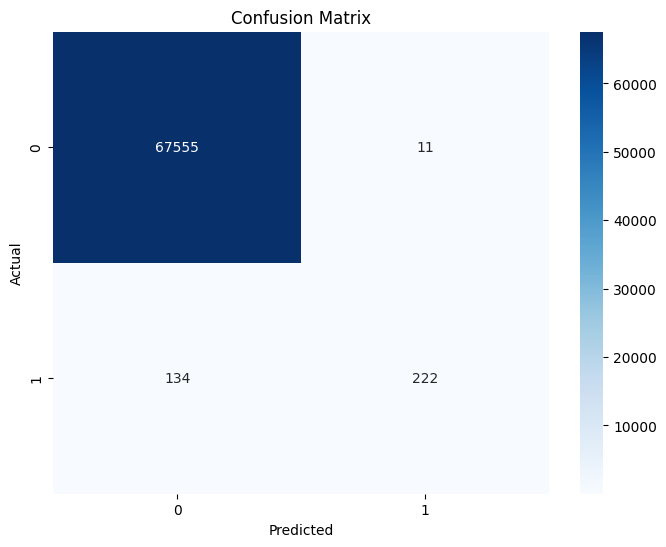

In [36]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, output_dict=False)

print(accuracy)
print(classification_rep)

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [35]:
print(accuracy)
print(classification_rep)

0.9978651983157151
{'0': {'precision': 0.9980203578129386, 'recall': 0.9998371962229524, 'f1-score': 0.998927950907545, 'support': 67566.0}, '1': {'precision': 0.9527896995708155, 'recall': 0.6235955056179775, 'f1-score': 0.7538200339558574, 'support': 356.0}, 'accuracy': 0.9978651983157151, 'macro avg': {'precision': 0.9754050286918771, 'recall': 0.811716350920465, 'f1-score': 0.8763739924317012, 'support': 67922.0}, 'weighted avg': {'precision': 0.9977832900832753, 'recall': 0.9978651983157151, 'f1-score': 0.9976432652617335, 'support': 67922.0}}


In [42]:
def balancing_the_imbalance(imbalance_method=None, weights=False):
  ngram_range = (1, 3)
  max_features = 400
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df['category'])

  if weights:
    class_weight = 'balanced'
  else:
    class_weight = None


  if imbalance_method == 'oversampling':
      smote = SMOTE(random_state=42)
      X_train, y_train = smote.fit_resample(X_train, y_train)
  elif imbalance_method == 'adasyn':
      adasyn = ADASYN(random_state=42)
      X_train, y_train = adasyn.fit_resample(X_train, y_train)
  elif imbalance_method == 'smote_enn':
      smote_enn = SMOTEENN(random_state=42)
      X_train, y_train = smote_enn.fit_resample(X_train, y_train)


  n_estimators = 200
  max_depth = 15

  model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, class_weight=class_weight)
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(accuracy)
  classification_rep = classification_report(y_test, y_pred)
  print(classification_rep)

  conf_matrix = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title(f"Confusion Matrix: Imbalance={imbalance_method}")
  plt.show()

0.9981007626394982
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67596
           1       0.81      0.79      0.80       326

    accuracy                           1.00     67922
   macro avg       0.91      0.89      0.90     67922
weighted avg       1.00      1.00      1.00     67922



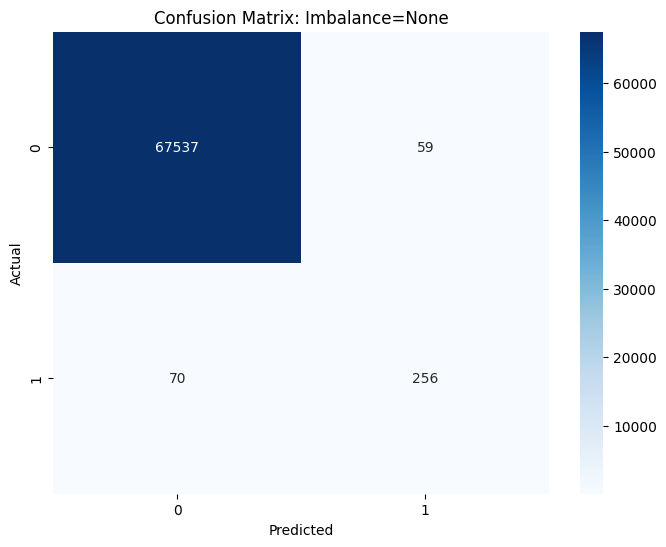

In [43]:
imbalance_methods = ['oversampling', 'adasyn', 'smote_enn']

balancing_the_imbalance(weights=True)

0.9947145254851153
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67596
           1       0.47      0.84      0.60       326

    accuracy                           0.99     67922
   macro avg       0.74      0.92      0.80     67922
weighted avg       1.00      0.99      1.00     67922



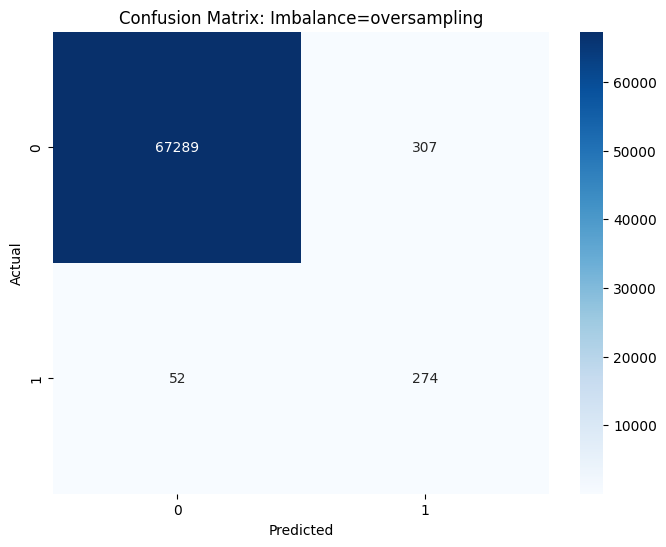

0.9924766644091753
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     67596
           1       0.37      0.83      0.51       326

    accuracy                           0.99     67922
   macro avg       0.69      0.91      0.76     67922
weighted avg       1.00      0.99      0.99     67922



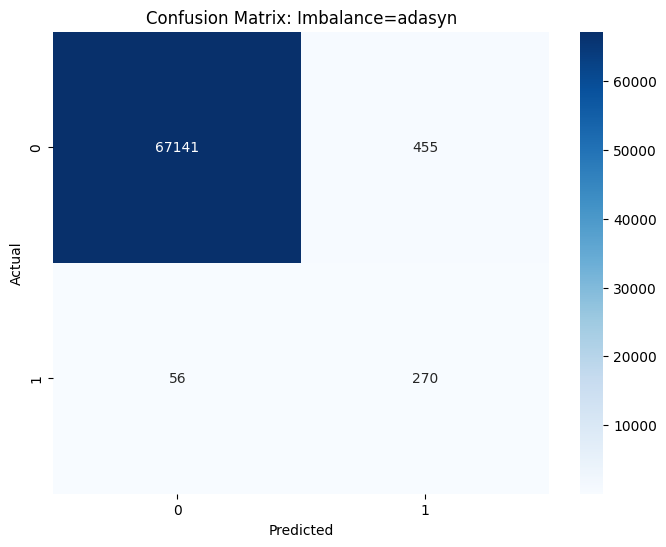

0.9901799122522894
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     67596
           1       0.31      0.86      0.46       326

    accuracy                           0.99     67922
   macro avg       0.66      0.92      0.73     67922
weighted avg       1.00      0.99      0.99     67922



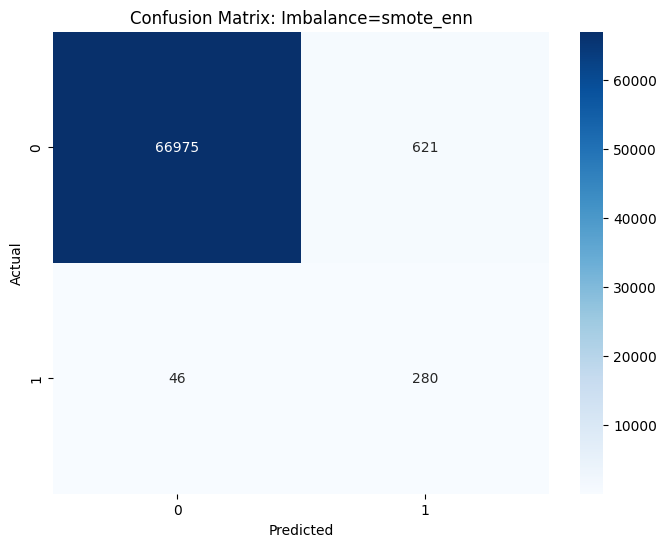

In [44]:
for method in imbalance_methods:
    balancing_the_imbalance(method)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df['category'])


def try_models(model_name, model, X_train, X_test, y_train, y_test, scaler=False):
  if (scaler):
    Scaler = StandardScaler()
    X_train = Scaler.fit_transform(X_train)
    X_test = Scaler.transform(X_test)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  print(accuracy_score(y_test, y_pred))
  print(classification_report(y_test, y_pred))

  conf_matrix = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title(f"Confusion Matrix: Model={model_name}")
  plt.show()

In [47]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
models = {
    "Linear SVC": LinearSVC(
        random_state=42
        ,class_weight='balanced'
        ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric="mlogloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1,
        class_weight='balanced'
    )
}


Linear SVC
0.8334560230853038
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     67596
           1       0.02      0.89      0.05       326

    accuracy                           0.83     67922
   macro avg       0.51      0.86      0.48     67922
weighted avg       0.99      0.83      0.90     67922



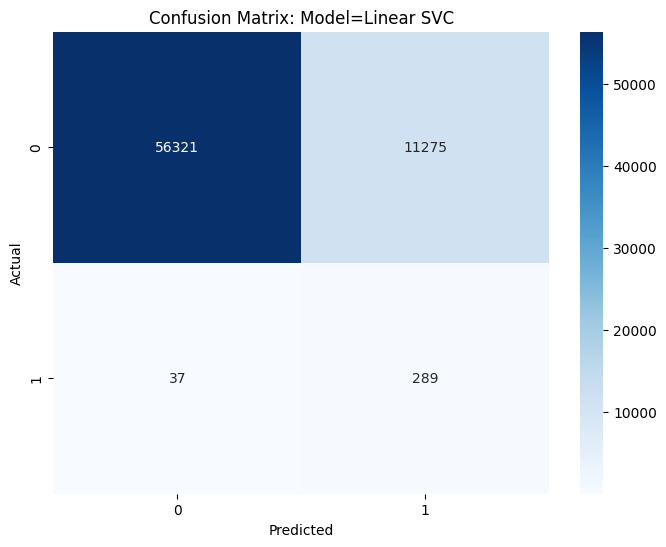


Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9297134948911987
              precision    recall  f1-score   support

           0       1.00      0.93      0.96     67596
           1       0.05      0.78      0.10       326

    accuracy                           0.93     67922
   macro avg       0.53      0.85      0.53     67922
weighted avg       0.99      0.93      0.96     67922



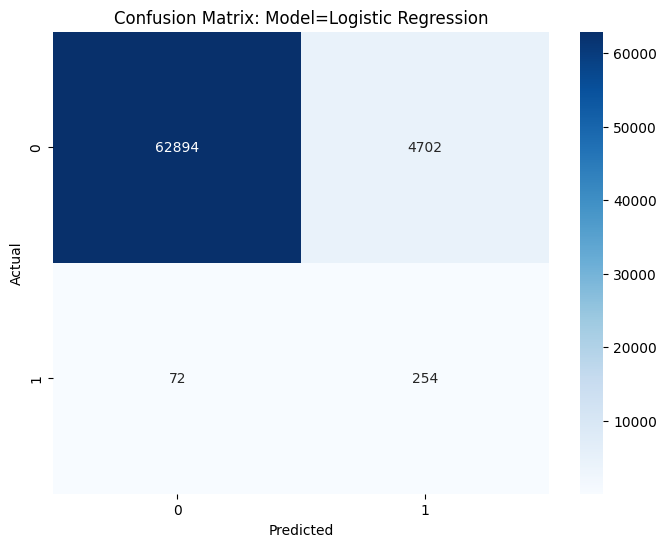


Random Forest
0.9983952180442272
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67596
           1       0.98      0.68      0.80       326

    accuracy                           1.00     67922
   macro avg       0.99      0.84      0.90     67922
weighted avg       1.00      1.00      1.00     67922



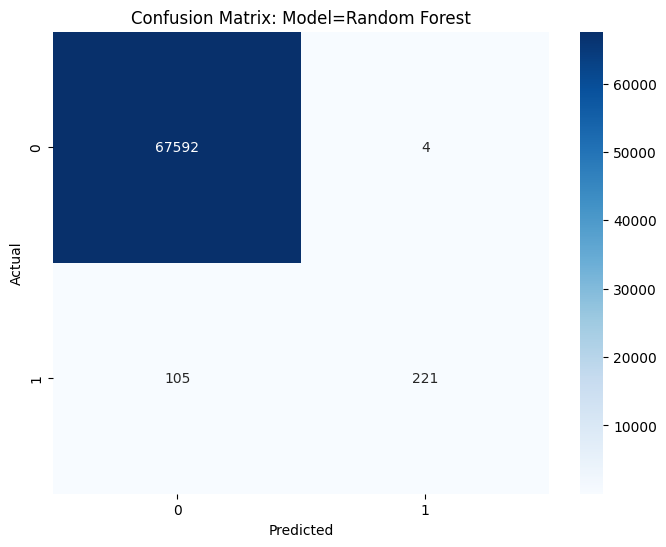


XGBoost
0.9986455051382468
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67596
           1       0.81      0.94      0.87       326

    accuracy                           1.00     67922
   macro avg       0.91      0.97      0.93     67922
weighted avg       1.00      1.00      1.00     67922



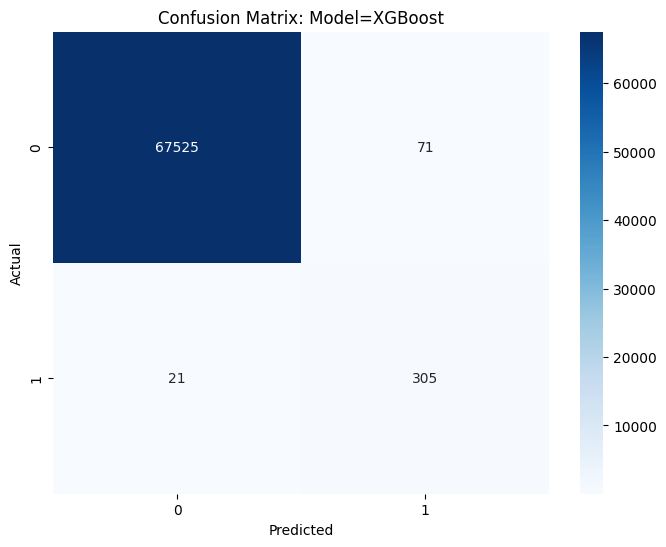


LightGBM
0.99283001089485
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     67596
           1       0.40      0.97      0.56       326

    accuracy                           0.99     67922
   macro avg       0.70      0.98      0.78     67922
weighted avg       1.00      0.99      0.99     67922



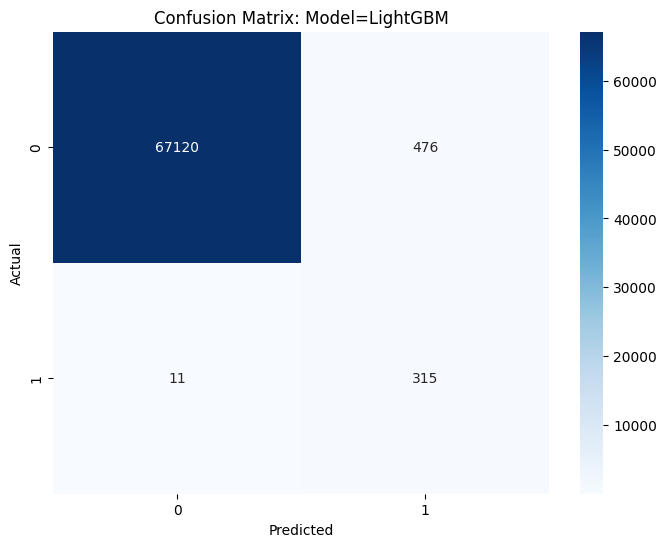

In [48]:
for name, model in models.items():
    print(f"\n{'='*60}")
    print(name)
    print(f"{'='*60}")

    try_models(
        name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

In [51]:
models = {
    "Linear SVC": LinearSVC(
        random_state=42
        ,class_weight='balanced'
        ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    )
}


Linear SVC
0.8402432201643061
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     67596
           1       0.03      0.87      0.05       326

    accuracy                           0.84     67922
   macro avg       0.51      0.86      0.48     67922
weighted avg       0.99      0.84      0.91     67922



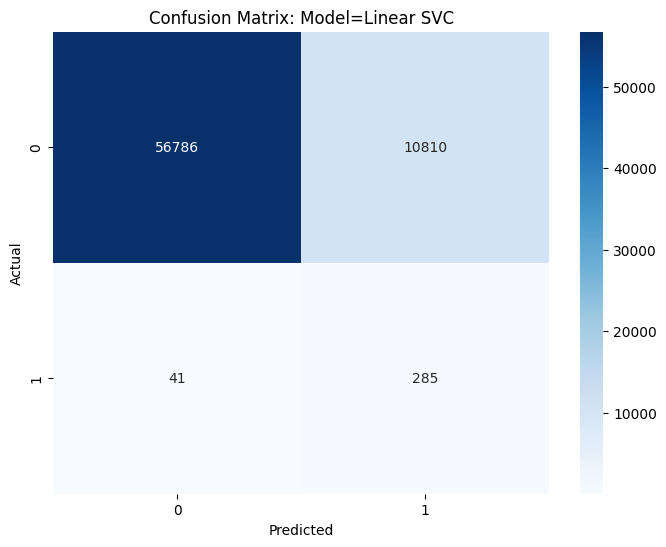


Logistic Regression
0.8526545154736315
              precision    recall  f1-score   support

           0       1.00      0.85      0.92     67596
           1       0.03      0.87      0.05       326

    accuracy                           0.85     67922
   macro avg       0.51      0.86      0.49     67922
weighted avg       0.99      0.85      0.92     67922



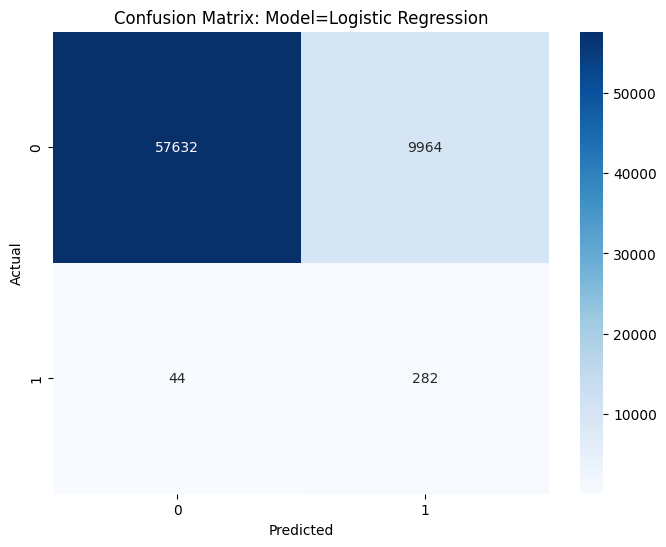

In [54]:
for name, model in models.items():
    print(f"\n{'='*60}")
    print(name)
    print(f"{'='*60}")

    try_models(
        name,
        model,
        X_train,
        X_test,
        y_train,
        y_test,
        scaler=True
    )

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df['category'])

best_model = XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric="mlogloss"
    )
best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

0.9986455051382468
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67596
           1       0.81      0.94      0.87       326

    accuracy                           1.00     67922
   macro avg       0.91      0.97      0.93     67922
weighted avg       1.00      1.00      1.00     67922



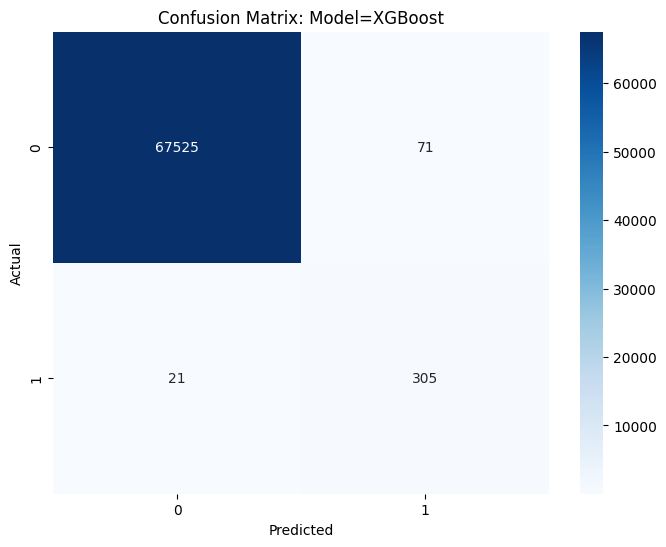

In [58]:
y_pred = best_model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: Model=XGBoost")
plt.show()

In [60]:
import pickle
with open ("cc_fraud_detection", "wb") as f:
  pickle.dump(best_model, f)